# Classification using a Support Vector Machine (SVM)

Multivariate pattern analysis (MVPA) has emerged as a powerful tool in human electrophysiological research, enabling the investigation of representational content encoded in spatially distributed patterns of brain activity [1,3]. Unlike traditional univariate approaches, which examine changes in activity at individual sensors or regions, MVPA leverages the combined information across multiple channels to detect subtle and spatially distributed neural representations. In the present example, we illustrate how a support vector machine (SVM) classifier can be used to decode brain activity patterns associated with lateralised cue processing—specifically, to discriminate between neural responses elicited by left- versus right-sided cues.

## Preparation

Below are the required Python modules to be imported

In [1]:
import os.path as op
import os
import sys
import matplotlib.pyplot as plt
import numpy as np
import mne
from mne_bids import BIDSPath
from mne.decoding import (SlidingEstimator, GeneralizingEstimator, Scaler,
                          cross_val_multiscore, LinearModel, get_coef,
                          Vectorizer, CSP)

import sklearn.svm
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from scipy.signal import detrend

The classification is based on the tools in the *Scikit-Learn* package.

## File overview

This chapter relies on the epoched data produced in an earlier chapter (embedded in the BIDS structure):

`<BIDS_ROOT>/derivatives/analysis/sub-01/ses-01/meg/sub-01_ses-01_task-SpAtt_run-01_epo.fif`

Set the paths for the data below. Note that these will depend on your local setup.

## Specify your BIDS parameters along with the BIDS folder path

In [2]:
subject = '01'
session = '01'
task    = 'SpAtt'
run     = '01'
meg_suffix = 'meg'
epo_suffix = 'epo'

# Root folder holding the BIDS dataset. Adjust to your local setup.
#data_path = 'C:/Users/rakshita/Documents/Cerca_raw_files'
data_path = '/Users/o.jensen@bham.ac.uk/Data/CercaOxf/subjB/Data'



bids_root  = op.join(data_path, "Cerca_Spatt_BIDS")
deriv_root = op.join(bids_root, "derivatives/analysis")

# Path to the epoched data (input)
bids_path = BIDSPath(subject=subject, session=session,
            task=task, run=run, suffix=epo_suffix, datatype='meg',
            root=deriv_root, extension='.fif', check=False)

print(bids_path.basename, bids_path.fpath)

sub-01_ses-01_task-SpAtt_run-01_epo.fif /Users/o.jensen@bham.ac.uk/Data/CercaOxf/subjB/Data/Cerca_Spatt_BIDS/derivatives/analysis/sub-01/ses-01/meg/sub-01_ses-01_task-SpAtt_run-01_epo.fif


## Reading and preparing the trial based data

Read the epochs:

In [3]:
epochs = mne.read_epochs(bids_path.fpath,
                         preload=True,
                         verbose=True).pick(['meg'])

Reading /Users/o.jensen@bham.ac.uk/Data/CercaOxf/subjB/Data/Cerca_Spatt_BIDS/derivatives/analysis/sub-01/ses-01/meg/sub-01_ses-01_task-SpAtt_run-01_epo.fif ...
    Read a total of 8 projection items:
        HFC: l=1 m=0 (1 x 170) active
        HFC: l=2 m=0 (1 x 170) active
        HFC: l=1 m=-1 (1 x 170) active
        HFC: l=1 m=1 (1 x 170) active
        HFC: l=2 m=-1 (1 x 170) active
        HFC: l=2 m=1 (1 x 170) active
        HFC: l=2 m=-2 (1 x 170) active
        HFC: l=2 m=2 (1 x 170) active
    Found the data of interest:
        t =    -749.33 ...    2000.00 ms
        0 CTF compensation matrices available
Not setting metadata
295 matching events found
No baseline correction applied
Created an SSP operator (subspace dimension = 8)
8 projection items activated


Now low-pass filter the data at 45 Hz to suppress high-frequency noise. Filtering is applied to the whole epoch (before it is cropped below) so that the filter edge effects fall outside the −0.1 to 1.5 s window we keep. Rather than also high-pass filtering, slow drifts are removed later by a per-trial linear detrend (see below). The low-pass additionally smooths the data in time, which benefits the classifier.

In [4]:
epochs_rs = epochs.copy().filter(None,45)

Setting up low-pass filter at 45 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal lowpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Upper passband edge: 45.00 Hz
- Upper transition bandwidth: 11.25 Hz (-6 dB cutoff frequency: 50.62 Hz)
- Filter length: 221 samples (0.295 s)



In [5]:
print(epochs.event_id)

{'cue_Left': 2, 'cue_Right': 3}


Down-sample the data to 125 Hz in order to reduce the computation time of the classification. Then set the time-window of interest to -0.1 to 1.5 s around the cue onset.

In [6]:
epochs_rs.resample(125)
epochs_rs.crop(tmin=-0.1, tmax=1.5)

<EpochsFIF | 295 events (all good), -0.093 – 1.507 s (baseline off), ~78.6 MiB, data loaded,
 'cue_Left': 144
 'cue_Right': 151>

## Setting up the Classifier

The SVM is implemented in the *Scikit-Learn* package and the corresponding application programming interface (API) must be applied. The feature matrix `X` is three-dimensional (*trials* × *sensors* × *samples*). We extract it with `get_data` and remove a linear trend from each trial (per sensor) to suppress any residual slow drift.

In [7]:
X = epochs_rs.get_data(picks='meg') 
X = detrend(X, axis=-1, type='linear')
X.shape

(295, 170, 201)

We have 213 trials, each with 201 samples (time points). The target vector *y* contains 109 left and 104 right trials. The trial codes (5 and 6) need to be converted to the class labels 1 and 2.

In [8]:
epochs.events[:10,:]

array([[ 9090,     0,     3],
       [12985,     0,     2],
       [15823,     0,     2],
       [19160,     0,     3],
       [22430,     0,     3],
       [26243,     0,     3],
       [30118,     0,     2],
       [32632,     0,     2],
       [36494,     0,     3],
       [39594,     0,     2]], dtype=int32)

In [9]:
# Copy first so we don't modify epochs.events in place; map trigger codes 5/6 -> labels 1/2
y = epochs.events[:, 2].copy()
y[y == 2] = 1
y[y == 3] = 2
print(y)

[2 1 1 2 2 2 1 1 2 1 2 2 2 2 1 1 1 2 2 1 2 2 1 2 2 1 1 2 1 1 2 1 2 1 2 1 1
 2 2 1 1 1 2 2 2 1 1 2 1 2 2 2 1 2 2 1 1 1 1 1 1 1 2 1 1 2 2 1 2 2 2 1 1 1
 2 1 2 1 2 1 2 2 2 2 2 1 1 2 1 2 1 1 2 2 2 2 1 2 1 2 2 2 1 2 1 1 1 2 1 1 1
 1 1 2 2 1 2 1 2 1 1 2 1 1 2 1 2 1 1 1 2 2 1 1 1 2 2 2 1 2 1 1 1 2 2 1 2 1
 2 1 1 2 2 2 2 2 1 2 2 2 2 2 2 2 1 2 1 1 1 1 1 1 1 2 1 2 2 2 2 1 2 2 2 1 1
 1 2 2 2 1 2 1 1 2 2 2 2 1 2 1 1 1 1 1 2 2 2 2 1 1 2 2 2 1 2 1 1 1 1 2 1 1
 1 2 1 1 2 1 2 1 2 1 1 1 2 2 1 2 2 2 2 1 1 2 1 2 2 1 2 2 2 1 1 1 2 2 1 1 2
 2 2 1 1 1 2 1 1 2 2 2 1 2 1 1 1 1 2 2 2 2 1 2 1 2 2 2 2 2 2 2 1 1 1 1 2]


The function `make_pipeline` is from [Scikit-Learn](https://scikit-learn.org/) . It defines the transforms used with the estimator. The `Vectorizer()` transforms `X` into a 2D array (samples by features). The `StandardScaler()` standardize the data by removing the mean and scaling to unit variance.

In [10]:
clf = make_pipeline(Vectorizer(),StandardScaler(),  
                   LinearModel(sklearn.svm.SVC(kernel = 'linear')))   

We now decode using a **sliding time window** rather than a single time sample. At each window position the features are all sensors across all the samples that fall within the window; the `Vectorizer` in the pipeline concatenates them into one feature vector. The window is then slid across the epoch, and a classifier is trained and tested at each position. Pooling several samples per window incorporates temporal information and yields a smoother time course, at the cost of temporal resolution. The aim remains to discriminate the conditions as a function of time: when can we tell left- from right-cued attention?

In [11]:
# Length of the sliding time window
sfreq = epochs_rs.info['sfreq']
win_dur = 0.1                              # window length in seconds
win = int(round(win_dur * sfreq))          # window length in samples
step = 5                                   # step between successive windows (samples)
print(f"sliding window = {win} samples ({win_dur*1000:.0f} ms), step = {step}")

sliding window = 12 samples (100 ms), step = 5


## Performing the Classification

The window is slid across the epoch. At each position a linear SVM is trained and tested using 10-fold cross-validation (cv=10): in each fold the classifier is trained on 90% of the trials and tested on the held-out 10%. Performance is reported as the Area Under the Curve (AUC) of the ROC, one value per window position. Note that this loop fits many classifiers and may take a little while; increase `step` to speed it up.

In [12]:
# Slide the window across time; run 10-fold cross-validation at each position
n_times = X.shape[-1]

scores = []
window_times = []
for start in range(0, n_times - win + 1, step):
    Xw = X[:, :, start:start + win]                                  # (trials, sensors, win)
    s = cross_val_multiscore(clf, Xw, y, cv=10, scoring='roc_auc', n_jobs=-1)
    scores.append(s)                                                 # (n_folds,) for this window
    window_times.append(epochs_rs.times[start:start + win].mean())  # window-centre time

scores = np.array(scores)                                            # (n_windows, n_folds)
window_times = np.array(window_times)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   4 out of  10 | elapsed:    3.7s remaining:    5.6s
[Parallel(n_jobs=-1)]: Done   7 out of  10 | elapsed:    3.7s remaining:    1.6s
[Parallel(n_jobs=-1)]: Done  10 out of  10 | elapsed:    3.8s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   4 out of  10 | elapsed:    0.1s remaining:    0.2s
[Parallel(n_jobs=-1)]: Done   7 out of  10 | elapsed:    0.2s remaining:    0.1s
[Parallel(n_jobs=-1)]: Done  10 out of  10 | elapsed:    0.2s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   4 out of  10 | elapsed:    0.1s remaining:    0.2s
[Parallel(n_jobs=-1)]: Done   7 out of  10 | elapsed:    0.2s remaining:    0.1s
[Parallel(n_jobs=-1)]: Done  10 out of  10 | elapsed:    0.2s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent worker

## Plotting the Results

In order to plot the results,average over scores and plot

In [13]:
scores = np.mean(scores, axis=1)   # average over the 10 folds -> one AUC per window

Text(0.5, 1.0, 'Sliding-window decoding of OPM data')

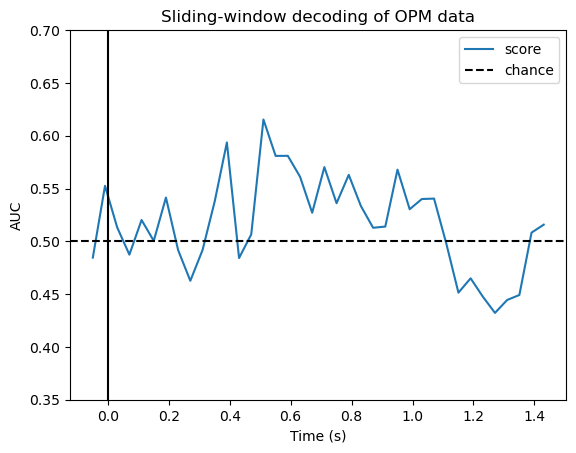

In [14]:
fig, ax = plt.subplots()
ax.plot(window_times, scores, label='score')
ax.axhline(.5, color='k', linestyle='--', label='chance')
ax.axvline(.0, color='k', linestyle='-')
ax.set_xlabel('Time (s)')
ax.set_ylabel('AUC')  # Area Under the Curve
ax.set_ylim([0.35, 0.70])
ax.legend()
ax.set_title('Sliding-window decoding of OPM data')

The plot shows the classification accuracy (AUC) as a function of the window-centre time. The best classification is obtained ~500 ms after cue onset, reaching about 0.62. Compared with single-sample decoding, the sliding window produces a smoother time course.

## Preregistration and publication

A preregistration should specify the decoding pipeline in enough detail to reproduce it exactly. The pre-processing, the classifier, the cross-validation scheme, and the scoring metric all affect decoding accuracy, so they should be fixed in advance. We recommend committing to the following:

**Data and features**
- The conditions decoded (here attend-left vs attend-right, from the cue events) and the sensors used (here all MEG/OPM channels).
- The pre-processing applied before decoding: low-pass filter (45 Hz), a per-trial linear detrend, downsampling (125 Hz), and the time window retained (−0.1 to 1.5 s around cue onset).
- Any standardisation (here per-feature mean removal and unit-variance scaling with `StandardScaler`).

**Classifier and validation**
- The estimator (a linear-kernel support vector machine [2]) and the decoding scheme (a sliding time window: at each position all sensors × all samples within a short window form the feature vector, and the window slides across the epoch).
- The window length and step (here a 100 ms window slid one sample at a time).
- The cross-validation scheme (here 10-fold) and the scoring metric (ROC AUC), together with the chance level (0.5).
- How statistical significance is assessed (e.g. cluster-based permutation tests across time), if applicable.

**General**
- Software and versions (MNE-Python, scikit-learn).

**Example methods text**

> "A multivariate pattern analysis was applied to the OPM-MEG data to classify whether participants attended left or right. The data were low-pass filtered at 45 Hz and downsampled to 125 Hz, the −0.1 to 1.5 s interval around cue onset was retained, and a linear trend was removed from each trial. Features were standardised (per-sensor mean removal and unit-variance scaling). A linear support vector machine [2] from scikit-learn (https://scikit-learn.org/) was applied within a sliding 100 ms time window (all sensors and all samples within the window forming the feature vector), sliding across the epoch. A 10-fold cross-validation procedure was used and performance was reported as the Area Under the ROC Curve."

## References

1. Cichy, R. M., Pantazis, D., & Oliva, A. (2014). Resolving human object recognition in space and time. *Nature Neuroscience*, 17(3), 455–462. https://doi.org/10.1038/nn.3635

2. Cortes, C., & Vapnik, V. (1995). Support-vector networks. *Machine Learning*, 20, 273–297.

3. Stokes, M. G., Wolff, M. J., & Spaak, E. (2015). Decoding rich spatial information with high temporal resolution. *Trends in Cognitive Sciences*, 19(11), 636–638. https://doi.org/10.1016/j.tics.2015.08.016

4. Duda, R. O., & Hart, P. E. (2006). *Pattern Classification* (2nd ed.). John Wiley & Sons.

5. Gramfort, A., Luessi, M., Larson, E., et al. (2013). MEG and EEG data analysis with MNE-Python. *Frontiers in Neuroscience*, 7, 267. https://doi.org/10.3389/fnins.2013.00267

6. Pedregosa, F., Varoquaux, G., Gramfort, A., et al. (2011). Scikit-learn: Machine learning in Python. *Journal of Machine Learning Research*, 12, 2825–2830.